# Prim's Algorithm — Minimum Spanning Tree (MST)

Finds a subset of edges connecting all nodes with the minimum possible total
edge weight, with no cycles — the Minimum Spanning Tree.

**Note:** MST is defined for undirected graphs. Since our transportation
network is modeled as directed, we treat it as undirected for MST purposes:
for every pair of connected cities, we consider the minimum-weight edge
between them in either direction (representing "the road connecting these
two cities," regardless of which direction was recorded).

Uses a min-priority queue: starting from an arbitrary node, repeatedly add
the cheapest edge that connects a new node to the growing tree.

- Time complexity: O(E log V) with a binary heap
- Space complexity: O(V + E)

In [7]:
class Graph:
    def __init__(self):
        self.adj = {}

    def add_node(self, node):
        if node not in self.adj:
            self.adj[node] = []

    def add_edge(self, u, v, weight):
        self.add_node(u)
        self.add_node(v)
        self.adj[u].append((v, weight))

    def nodes(self):
        return list(self.adj.keys())

    def edges(self):
        result = []
        for u in self.adj:
            for v, w in self.adj[u]:
                result.append((u, v, w))
        return result

    def neighbors(self, u):
        return self.adj.get(u, [])

    def num_nodes(self):
        return len(self.adj)

    def num_edges(self):
        return sum(len(v) for v in self.adj.values())

    def __repr__(self):
        lines = []
        for u in self.adj:
            for v, w in self.adj[u]:
                lines.append(f"  {u} -> {v}  (weight={w})")
        return f"Graph({self.num_nodes()} nodes, {self.num_edges()} edges)\n" + "\n".join(lines)


def to_undirected_adjacency(graph: Graph):
    """
    Builds an undirected adjacency view from a directed Graph, keeping the
    minimum weight when both directions (or duplicate edges) exist.
    """
    undirected = {node: {} for node in graph.nodes()}
    for u, v, w in graph.edges():
        if v not in undirected[u] or w < undirected[u][v]:
            undirected[u][v] = w
        if u not in undirected[v] or w < undirected[v][u]:
            undirected[v][u] = w
    return undirected

In [8]:
import heapq

def prim(graph: Graph, start=None, track_steps=False):
    """
    Returns (mst_edges, total_weight) — the MST as a list of (u, v, weight)
    edges, and the sum of all MST edge weights.

    If track_steps=True, also returns a list of step snapshots for visualization.
    """
    undirected = to_undirected_adjacency(graph)
    nodes = graph.nodes()
    if not nodes:
        return ([], 0) if not track_steps else ([], 0, [])

    start = start or nodes[0]
    visited = {start}
    mst_edges = []
    total_weight = 0
    steps = []

    # priority queue of (weight, u, v) — edge from visited node u to unvisited v
    pq = []
    for v, w in undirected[start].items():
        heapq.heappush(pq, (w, start, v))

    while pq and len(visited) < len(nodes):
        w, u, v = heapq.heappop(pq)
        if v in visited:
            continue

        visited.add(v)
        mst_edges.append((u, v, w))
        total_weight += w

        if track_steps:
            steps.append({
                "edge_added": (u, v, w),
                "visited": visited.copy(),
                "mst_edges_so_far": mst_edges.copy()
            })

        for nxt, weight in undirected[v].items():
            if nxt not in visited:
                heapq.heappush(pq, (weight, v, nxt))

    return (mst_edges, total_weight) if not track_steps else (mst_edges, total_weight, steps)

## Sanity Test

In [9]:
g = Graph()
edges = [
    ("Kathmandu", "Bhaktapur", 25),
    ("Kathmandu", "Lalitpur", 15),
    ("Lalitpur", "Bhaktapur", 20),
    ("Bhaktapur", "Dhulikhel", 30),
    ("Lalitpur", "Dhulikhel", 45),
    ("Dhulikhel", "Nagarkot", 35),
    ("Kathmandu", "Nagarkot", 60),
    ("Nagarkot", "Bhaktapur", 28),
]
for u, v, w in edges:
    g.add_edge(u, v, w)

mst_edges, total_weight = prim(g, start="Kathmandu")

print("MST edges:")
for u, v, w in mst_edges:
    print(f"  {u} -- {v}  (weight={w})")
print(f"\nTotal MST weight: {total_weight}")
print(f"Number of MST edges: {len(mst_edges)}  (should be {g.num_nodes() - 1} for {g.num_nodes()} nodes)")

MST edges:
  Kathmandu -- Lalitpur  (weight=15)
  Lalitpur -- Bhaktapur  (weight=20)
  Bhaktapur -- Nagarkot  (weight=28)
  Bhaktapur -- Dhulikhel  (weight=30)

Total MST weight: 93
Number of MST edges: 4  (should be 4 for 5 nodes)


## Visualizing the Minimum Spanning Tree

In [10]:
print("mst_edges currently in memory:", mst_edges)
print("total_weight currently in memory:", total_weight)

mst_edges currently in memory: [('Kathmandu', 'Lalitpur', 15), ('Lalitpur', 'Bhaktapur', 20), ('Bhaktapur', 'Nagarkot', 28), ('Bhaktapur', 'Dhulikhel', 30)]
total_weight currently in memory: 93


Edge highlight check:
  Kathmandu -- Bhaktapur (w=25): gray
  Kathmandu -- Lalitpur (w=15): HIGHLIGHTED
  Kathmandu -- Nagarkot (w=60): gray
  Bhaktapur -- Dhulikhel (w=30): HIGHLIGHTED
  Bhaktapur -- Lalitpur (w=20): HIGHLIGHTED
  Bhaktapur -- Nagarkot (w=28): HIGHLIGHTED
  Lalitpur -- Dhulikhel (w=45): gray
  Nagarkot -- Dhulikhel (w=35): gray


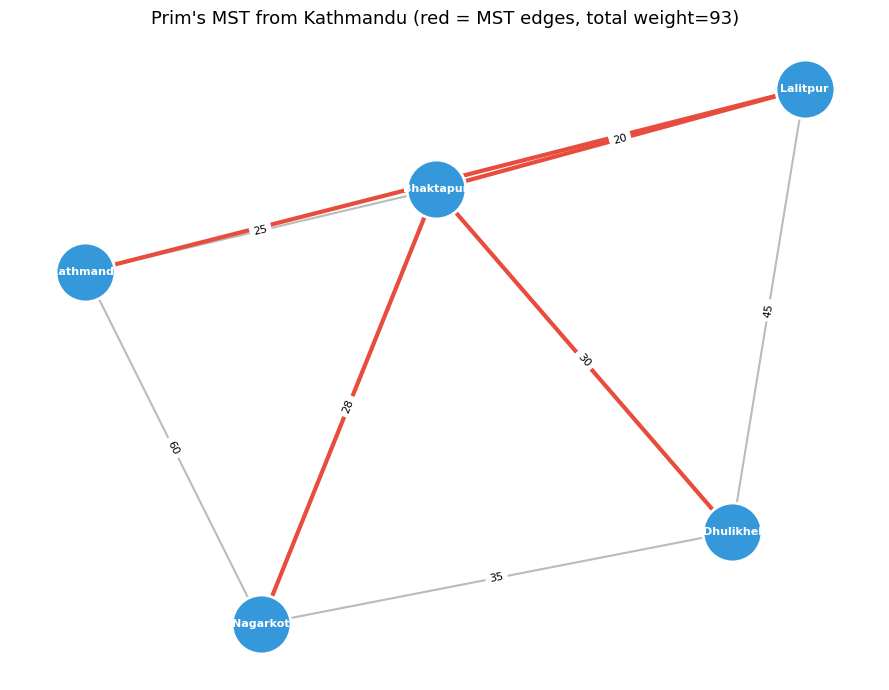

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_undirected_graph(graph, title="Graph", highlight_edges=None, node_labels=None):
    """
    Draws graph.edges() as an undirected graph (collapsing directed duplicates,
    keeping min weight). highlight_edges: set of frozenset({u, v}) pairs to highlight.
    """
    G = nx.Graph()
    for u, v, w in graph.edges():
        if not G.has_edge(u, v) or w < G[u][v]['weight']:
            G.add_edge(u, v, weight=w)

    highlight_edges = highlight_edges or set()

    pos = nx.spring_layout(G, seed=7, k=1.5)
    plt.figure(figsize=(9, 7))

    edge_colors, edge_widths = [], []
    print("Edge highlight check:")
    for u, v in G.edges():
        is_hl = frozenset({u, v}) in highlight_edges
        edge_colors.append('#e74c3c' if is_hl else '#bbbbbb')
        edge_widths.append(3 if is_hl else 1.5)
        print(f"  {u} -- {v} (w={G[u][v]['weight']}): {'HIGHLIGHTED' if is_hl else 'gray'}")

    nx.draw_networkx_nodes(G, pos, node_color='#3498db', node_size=1800, edgecolors='white', linewidths=2)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths)

    labels = {n: (f"{n}\n({node_labels[n]})" if node_labels and n in node_labels else n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold', font_color='white')

    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


mst_edge_set = {frozenset({u, v}) for u, v, w in mst_edges}
draw_undirected_graph(g, title=f"Prim's MST from Kathmandu (red = MST edges, total weight={total_weight})",
                       highlight_edges=mst_edge_set)

## Step-by-Step MST Construction

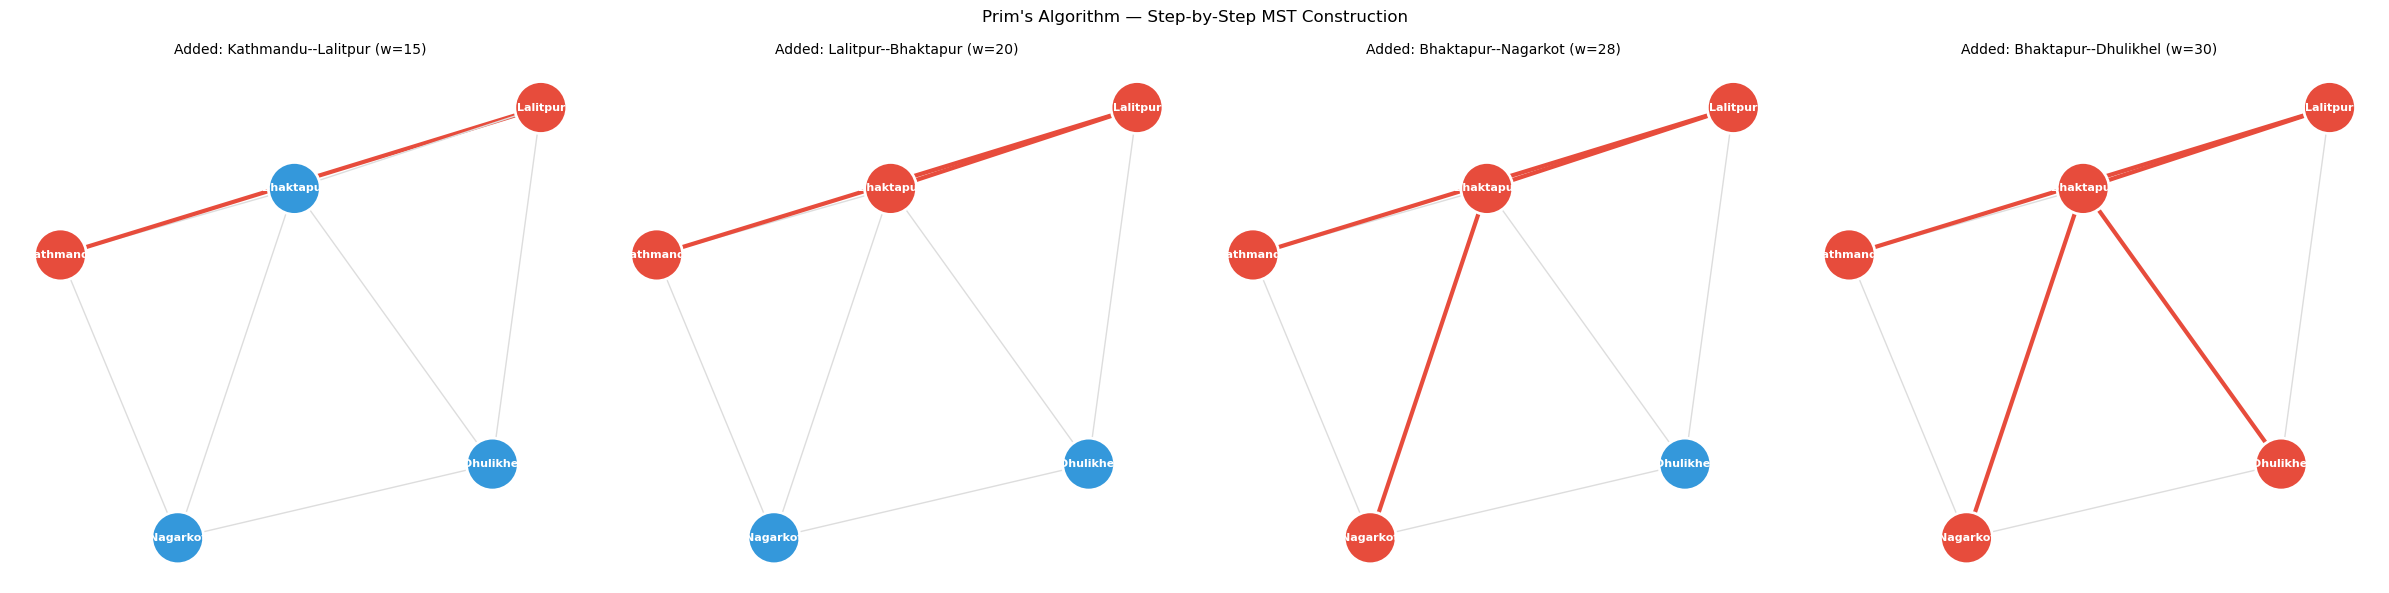

In [13]:
mst_edges2, total_weight2, steps = prim(g, start="Kathmandu", track_steps=True)

fig, axes = plt.subplots(1, len(steps), figsize=(6 * len(steps), 6))
if len(steps) == 1:
    axes = [axes]

G = nx.Graph()
for u, v, w in g.edges():
    if not G.has_edge(u, v) or w < G[u][v]['weight']:
        G.add_edge(u, v, weight=w)
pos = nx.spring_layout(G, seed=7, k=1.5)

for ax, step in zip(axes, steps):
    edges_so_far = {frozenset({u, v}) for u, v, w in step["mst_edges_so_far"]}
    visited = step["visited"]

    node_colors = ['#e74c3c' if n in visited else '#3498db' for n in G.nodes()]
    edge_colors = ['#e74c3c' if frozenset({u, v}) in edges_so_far else '#dddddd' for u, v in G.edges()]
    edge_widths = [3 if frozenset({u, v}) in edges_so_far else 1 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1400, edgecolors='white', linewidths=2)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold', font_color='white')

    u, v, w = step["edge_added"]
    ax.set_title(f"Added: {u}--{v} (w={w})", fontsize=10)
    ax.axis('off')

plt.suptitle("Prim's Algorithm — Step-by-Step MST Construction", fontsize=12)
plt.tight_layout()
plt.show()